# Clasificación de Rayos-X de Tórax — CNN desde Cero
## Semana 2 · Arquitecturas Avanzadas de Deep Learning

**Dataset:** [Chest X-Ray 6 Classes Dataset — Kaggle](https://www.kaggle.com/datasets/mohamedasak/chest-x-ray-6-classes-dataset)

---
### 1. Selección y Justificación del Problema

**Problema:** Clasificación automática de radiografías de tórax en 6 categorías de condiciones pulmonares/torácicas.

**Justificación de la arquitectura CNN:**
Las imágenes de rayos-X son datos espaciales 2D donde los patrones locales (nódulos, infiltrados, cardiomegalia) son detectables mediante filtros convolucionales. Las CNN son la solución óptima porque:
- **Invarianza traslacional:** Los filtros detectan patrones en cualquier zona de la imagen.
- **Jerarquía de características:** Capas tempranas capturan bordes/texturas; capas profundas capturan estructuras anatómicas complejas.
- **Eficiencia paramétrica:** El peso compartido reduce drásticamente los parámetros vs. una red densa.
- **Evidencia empírica:** CNN dominan benchmarks de imagen médica (CheXNet, etc.).

Una RNN no sería adecuada (datos no secuenciales) ni un Transformer puro (requeriría mucho más dato para converger desde cero).

---
## Instalación y Configuración del Entorno

In [ ]:
# Instalar kaggle API para descargar el dataset
#!pip install kaggle -q

import os, zipfile, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
import kagglehub
from google.colab import userdata
from PIL import Image
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

# Verificar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU detectada: {gpus[0].name}')
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print('Sin GPU — el entrenamiento será más lento. Activar en: Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU')

TensorFlow version: 2.20.0
GPU disponible: True
GPU detectada: /physical_device:GPU:0


---
## Descarga del Dataset desde Kaggle

**Instrucciones para obtener `kaggle.json`:**
1. Ingresar a https://www.kaggle.com → Account → API → *Create New Token*
2. Subir el archivo `kaggle.json` descargado usando la celda de abajo.

In [ ]:
# Autenticación con los Secrets de Colab (ícono en el panel izquierdo)

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_4a2f8524f5537f6f55610c520ff2757a'

path = kagglehub.dataset_download("mohamedasak/chest-x-ray-6-classes-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-x-ray-6-classes-dataset' dataset.
Path to dataset files: /kaggle/input/chest-x-ray-6-classes-dataset


In [ ]:
# Ver estructura completa del dataset
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # mostrar hasta 2 niveles
        for f in files[:3]:  # solo 3 archivos de muestra
            print(f'  {indent}{f}')

chest-x-ray-6-classes-dataset/
  chest-xray/
    val/
      Tuberculosis/
      Normal/
      Covid-19/
      Emphysema/
      Pneumonia-Viral/
      Pneumonia-Bacterial/
    test/
      Tuberculosis/
      Normal/
      Covid-19/
      Emphysema/
      Pneumonia-Viral/
      Pneumonia-Bacterial/
    train/
      Tuberculosis/
      Normal/
      Covid-19/
      Emphysema/
      Pneumonia-Viral/
      Pneumonia-Bacterial/


In [ ]:
# ── Cargar datasets ──────────────────────────────────────────────────────────
TRAIN_DIR = os.path.join(path, 'chest-xray', 'train')
VAL_DIR   = os.path.join(path, 'chest-xray', 'val')
TEST_DIR  = os.path.join(path, 'chest-xray', 'test')

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# Cargar SIN transformar aún para guardar class_names
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='int', shuffle=True, seed=42
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='int', shuffle=False
)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='int', shuffle=False
)

# Guardar class_names ANTES de transformar
CLASS_NAMES = train_ds_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f'Clases ({NUM_CLASSES}): {CLASS_NAMES}')

# Ahora sí aplicar normalización y pipeline
normalization = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_raw.map(lambda x, y: (normalization(x), y)).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.map(lambda x, y: (normalization(x), y)).cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.map(lambda x, y: (normalization(x), y)).cache().prefetch(AUTOTUNE)

print('Data lista')

Found 14551 files belonging to 6 classes.
Found 1748 files belonging to 6 classes.
Found 1737 files belonging to 6 classes.
Clases (6): ['Covid-19', 'Emphysema', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'Tuberculosis']
Data lista


---
## 2. Ficha Técnica y Estructuración de Datos

Clases (6): ['Covid-19', 'Emphysema', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'Tuberculosis']
           FICHA TÉCNICA DEL DATASET
  Nombre       : ChestX6 — Multi-Class X-ray Dataset
  Fuente       : Kaggle (mohamedasak)
  Tarea        : Clasificación multiclase (6 clases)
  Total imgs   : 18,036
  Resolución   : 224–224 × 224–224 px (variable)
  Res. destino : 128 × 128 px
  Canales      : RGB (3 canales)
  Normalización: Píxeles / 255 → rango [0, 1]
  Variable obj : Diagnóstico radiológico (6 categorías)
  Formato sal. : Entero → Softmax (6 neuronas)
  División     : Predefinida por el dataset (no aleatoria)
────────────────────────────────────────────────────────────
  Clase                      Train    Val   Test   Total
────────────────────────────────────────────────────────────
  Covid-19                    2417    300    300    3017
  Emphysema                   2050    250    250    2550
  Normal                      2671    300    300    3271
  Pneumonia-Bacteri

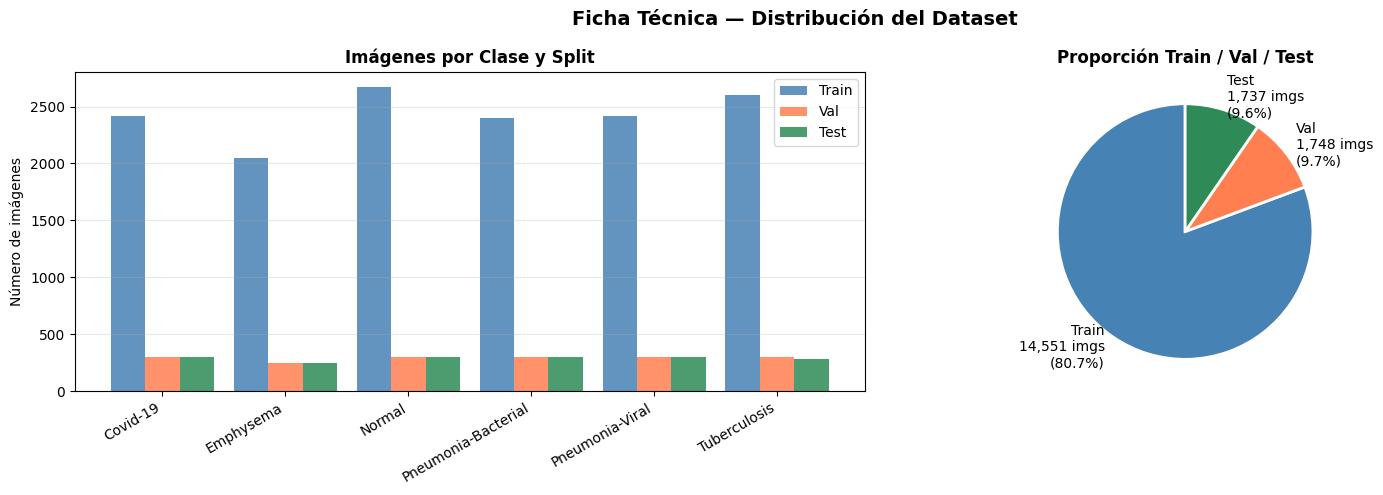

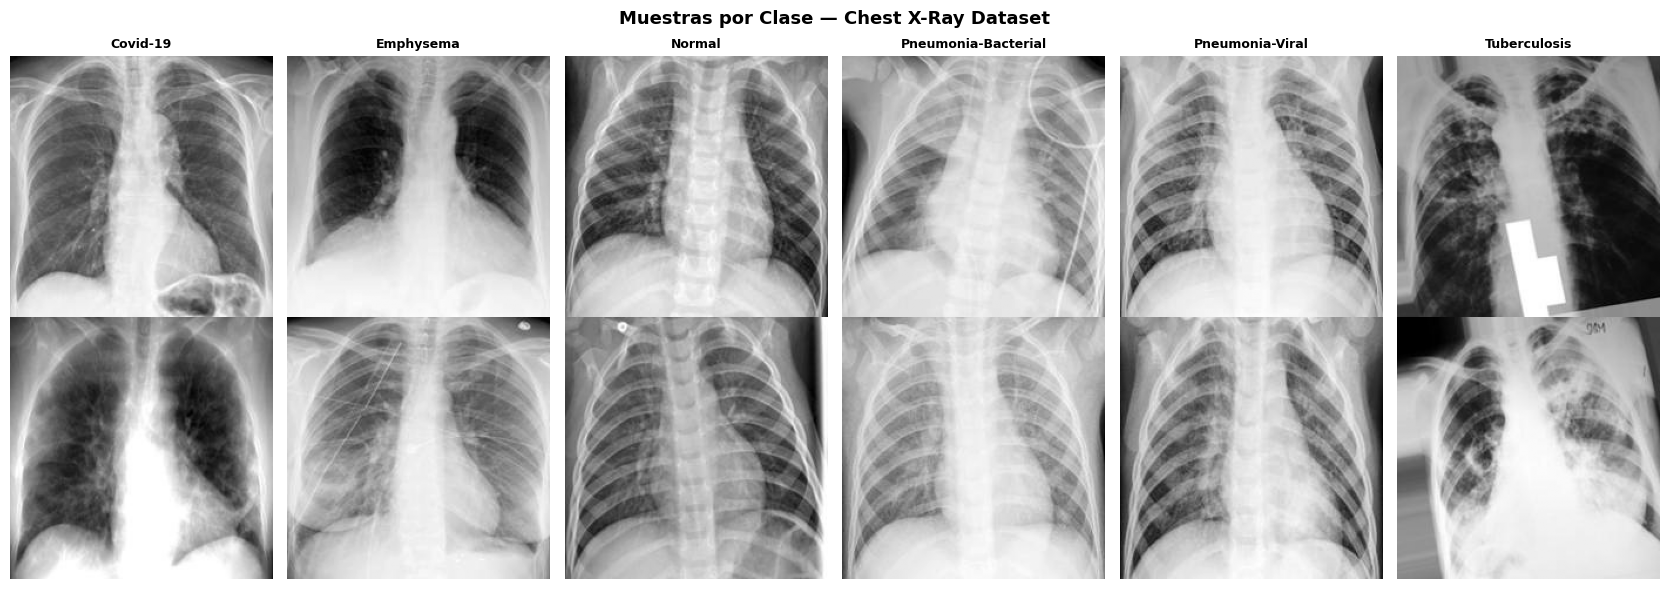

In [ ]:
# ── PUNTO 2: Ficha Técnica y Estructuración de Datos ─────────────────────────

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f'Clases ({NUM_CLASSES}): {CLASS_NAMES}')

# Contar imágenes reales por split y clase
def contar_imagenes(base_dir):
    conteo = {}
    total = 0
    for cls in sorted(os.listdir(base_dir)):
        cls_path = os.path.join(base_dir, cls)
        if os.path.isdir(cls_path):
            n = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            conteo[cls] = n
            total += n
    return conteo, total

train_counts, train_total = contar_imagenes(TRAIN_DIR)
val_counts,   val_total   = contar_imagenes(VAL_DIR)
test_counts,  test_total  = contar_imagenes(TEST_DIR)
grand_total = train_total + val_total + test_total

# Muestrear resoluciones reales
resoluciones = []
for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = os.listdir(cls_path)[:3]
    for img_name in imgs:
        try:
            with Image.open(os.path.join(cls_path, img_name)) as img:
                resoluciones.append(img.size)
        except:
            pass

widths  = [r[0] for r in resoluciones]
heights = [r[1] for r in resoluciones]

# ── Imprimir ficha técnica ───────────────────────────────────────────────────
print('=' * 60)
print('           FICHA TÉCNICA DEL DATASET')
print('=' * 60)
print(f'  Nombre       : ChestX6 — Multi-Class X-ray Dataset')
print(f'  Fuente       : Kaggle (mohamedasak)')
print(f'  Tarea        : Clasificación multiclase (6 clases)')
print(f'  Total imgs   : {grand_total:,}')
print(f'  Resolución   : {min(widths)}–{max(widths)} × {min(heights)}–{max(heights)} px (variable)')
print(f'  Res. destino : 128 × 128 px')
print(f'  Canales      : RGB (3 canales)')
print(f'  Normalización: Píxeles / 255 → rango [0, 1]')
print(f'  Variable obj : Diagnóstico radiológico (6 categorías)')
print(f'  Formato sal. : Entero → Softmax (6 neuronas)')
print(f'  División     : Predefinida por el dataset (no aleatoria)')
print('─' * 60)
print(f'  {"Clase":<25} {"Train":>6} {"Val":>6} {"Test":>6} {"Total":>7}')
print('─' * 60)
for cls in CLASS_NAMES:
    tr = train_counts.get(cls, 0)
    va = val_counts.get(cls, 0)
    te = test_counts.get(cls, 0)
    print(f'  {cls:<25} {tr:>6} {va:>6} {te:>6} {tr+va+te:>7}')
print('─' * 60)
print(f'  {"TOTAL":<25} {train_total:>6} {val_total:>6} {test_total:>6} {grand_total:>7}')
print(f'  {"PORCENTAJE":<25} {train_total/grand_total*100:>5.1f}% {val_total/grand_total*100:>5.1f}% {test_total/grand_total*100:>5.1f}%')
print('=' * 60)

# ── Gráfica de distribución por split ───────────────────────────────────────
x = np.arange(NUM_CLASSES)
width = 0.28

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Ficha Técnica — Distribución del Dataset', fontsize=14, fontweight='bold')

# Barras agrupadas por split
bars1 = axes[0].bar(x - width, [train_counts.get(c,0) for c in CLASS_NAMES], width, label='Train', color='steelblue',  alpha=0.85)
bars2 = axes[0].bar(x,         [val_counts.get(c,0)   for c in CLASS_NAMES], width, label='Val',   color='coral',      alpha=0.85)
bars3 = axes[0].bar(x + width, [test_counts.get(c,0)  for c in CLASS_NAMES], width, label='Test',  color='seagreen',   alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
axes[0].set_title('Imágenes por Clase y Split', fontweight='bold')
axes[0].set_ylabel('Número de imágenes')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

# Pie chart del total por split
axes[1].pie(
    [train_total, val_total, test_total],
    labels=[f'Train\n{train_total:,} imgs\n({train_total/grand_total*100:.1f}%)',
            f'Val\n{val_total:,} imgs\n({val_total/grand_total*100:.1f}%)',
            f'Test\n{test_total:,} imgs\n({test_total/grand_total*100:.1f}%)'],
    colors=['steelblue', 'coral', 'seagreen'],
    autopct='',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción Train / Val / Test', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/ficha_tecnica.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Muestras visuales del dataset ───────────────────────────────────────────
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 2.8, 6))
fig.suptitle('Muestras por Clase — Chest X-Ray Dataset', fontsize=13, fontweight='bold')

for col, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for row in range(2):
        img = plt.imread(os.path.join(cls_path, imgs[row]))
        axes[row, col].imshow(img, cmap='gray' if img.ndim == 2 else None)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(cls, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/muestras_clases.png', dpi=150, bbox_inches='tight')
plt.show()

El dataset ChestX6 contiene 18,036 radiografías de tórax distribuidas en 6 clases de condiciones pulmonares: Covid-19, Emphysema, Normal, Pneumonia-Bacterial, Pneumonia-Viral y Tuberculosis. La división predefinida por el autor asigna el 80.7% al entrenamiento (14,551 imágenes), 9.7% a validación (1,748) y 9.6% a test (1,737), lo cual es una proporción generalmente utilizada que maximiza los datos disponibles para el aprendizaje.
Respecto al balance de clases, el dataset es relativamente equilibrado.

La clase con más imágenes es Normal (3,271) y la que presenta una menor cantidad de datos es Emphysema (2,550), una diferencia de apenas 28% entre extremos, lo que significa que el desbalance no es severo. Sin embargo, se aplicará "class_weight" durante el entrenamiento como medida preventiva para que el modelo no desarrolle sesgo hacia las clases mayoritarias. Todas las imágenes tienen resolución nativa de 224x224 pixeles y se reescalan a 128x128 pixeles para reducir el costo computacional manteniendo suficiente detalle anatómico para la clasificación.

---
## 3. Flujo de Preprocesamiento Específico

La división del dataset es predefinida por el autor original, lo que garantiza una separación controlada y reproducible. Se respeta esta división para mantener la integridad experimental y permitir comparación con otros trabajos que usen el mismo dataset.El reescalado a 128x128 pixeles garantiza uniformidad en la entrada de la CNN, ya que las imágenes originales tienen resoluciones variables. La normalización en rango [0,1] divide cada píxel entre 255, lo que estabiliza el gradiente durante el backpropagation y acelera la convergencia del optimizador.El "data augmentation" se aplica exclusivamente al conjunto de entrenamiento para evitar data leakage. Las transformaciones elegidas (flip horizontal, rotación leve, zoom y contraste) simulan variaciones naturales en la toma de radiografías como diferencias de posicionamiento del paciente o ajustes del equipo, sin distorsionar la información clínica relevante.

Pipelines construidos:
  Train batches : 455
  Val batches   : 55
  Test batches  : 55
  Forma de batch : (32, 128, 128, 3)
  Rango pixeles  : [0.000, 1.000]


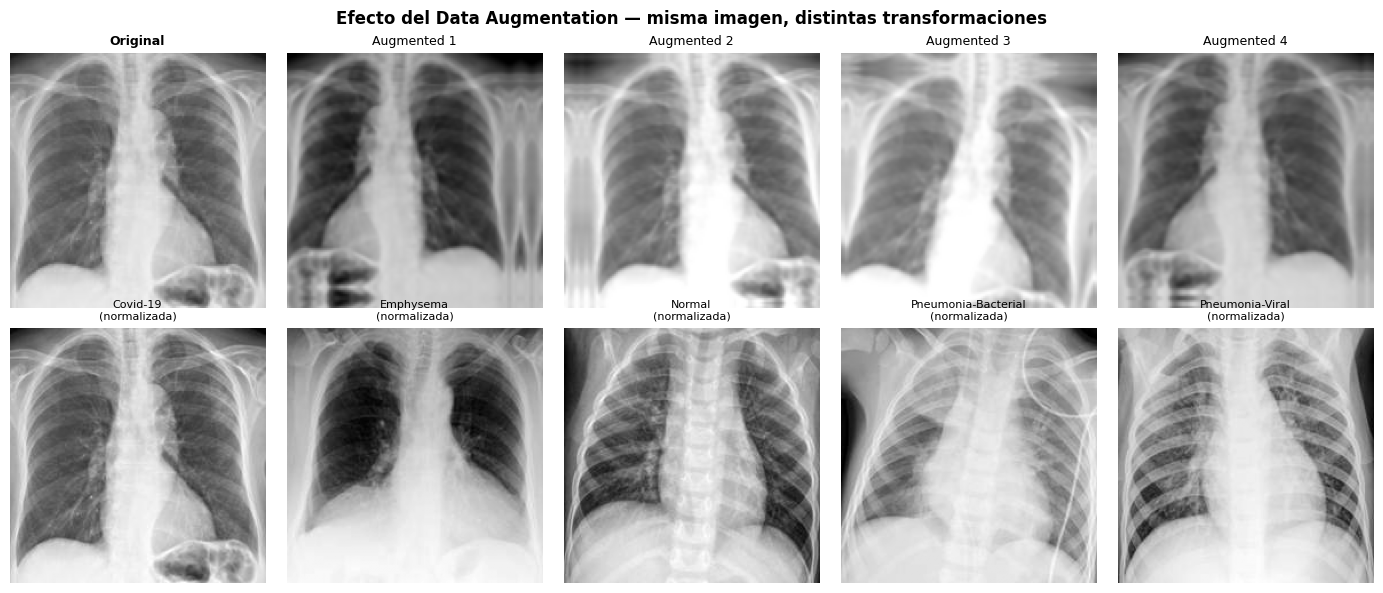

In [ ]:
# PUNTO 3: Flujo de Preprocesamiento Específico

# PASO 1: Data augmentation solo para train
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomBrightness(0.15),
    tf.keras.layers.RandomTranslation(0.10, 0.10)
], name='data_augmentation')

AUTOTUNE = tf.data.AUTOTUNE
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds_raw.map(
    lambda x, y: (normalization(data_augmentation(x, training=True)), y),
    num_parallel_calls=AUTOTUNE
).cache().shuffle(1000, seed=42).prefetch(AUTOTUNE)

val_ds = val_ds_raw.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

test_ds = test_ds_raw.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

print('Pipelines construidos:')
print(f'  Train batches : {len(train_ds)}')
print(f'  Val batches   : {len(val_ds)}')
print(f'  Test batches  : {len(test_ds)}')

for imgs, lbls in train_ds.take(1):
    print(f'  Forma de batch : {imgs.shape}')
    print(f'  Rango pixeles  : [{imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}]')

# Visualizar efecto del augmentation
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Efecto del Data Augmentation — misma imagen, distintas transformaciones',
             fontsize=12, fontweight='bold')

sample_img_path = os.path.join(TRAIN_DIR, CLASS_NAMES[0],
                  os.listdir(os.path.join(TRAIN_DIR, CLASS_NAMES[0]))[0])
sample_img = tf.image.resize(
    tf.image.decode_jpeg(tf.io.read_file(sample_img_path), channels=3),
    [128, 128]
)
sample_img = tf.expand_dims(sample_img, 0)

axes[0, 0].imshow(sample_img[0].numpy().astype('uint8'))
axes[0, 0].set_title('Original', fontsize=9, fontweight='bold')
axes[0, 0].axis('off')

for i in range(1, 5):
    aug = data_augmentation(sample_img, training=True)
    axes[0, i].imshow(tf.clip_by_value(aug[0] / 255.0, 0, 1).numpy())
    axes[0, i].set_title(f'Augmented {i}', fontsize=9)
    axes[0, i].axis('off')

# Mostrar una muestra normalizada de cada clase
for col, cls in enumerate(CLASS_NAMES[:5]):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img = plt.imread(os.path.join(cls_path, img_file))
    axes[1, col].imshow(img / 255.0 if img.max() > 1 else img, cmap='gray')
    axes[1, col].set_title(f'{cls}\n(normalizada)', fontsize=8)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('/content/preprocesamiento.png', dpi=150, bbox_inches='tight')
plt.show()

En la primera fila de imagenes se puede ver que la misma radiografía de Covid-19 fue sometida a 4 transformaciones distintas. Las variaciones de flip horizontal, rotación leve, zoom y contraste producen imágenes visualmente diferentes pero clínicamente equivalentes, es decir, siguen siendo radiografías válidas que un médico diagnosticaría igual. Esto es exactamente lo que se busca: aumentar artificialmente la diversidad del conjunto de entrenamiento sin introducir distorsiones que alteren el diagnóstico. El modelo aprenderá que esas variaciones corresponden a la misma clase, mejorando su generalización.

En la segunda fila Se muestran 5 de las 6 clases con sus imágenes ya en rango [0,1]. Se pueden observar diferencias morfológicas importantes que la CNN deberá aprender a distinguir a pesar que algunas de ellas presentan patrones similares como Pneumonia-Bacterial y Pneumonia-Viral lo cual puede causar problemas al momento de diferenciarlas.

---
## 4. Implementación de la Arquitectura CNN desde Cero

Arquitectura inspirada en VGG (bloques conv×2 + MaxPooling), **sin pesos pre-entrenados**.
Diseño progresivo: 32 → 64 → 128 → 256 filtros para capturar características de complejidad creciente.

In [ ]:
# ── Construcción de la CNN desde cero ────────────────────────────────────────

IMG_SIZE    = 128
CHANNELS    = 3
NUM_CLASSES = len(CLASS_NAMES)  # 6

def build_cnn_from_scratch(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
                            num_classes=NUM_CLASSES):
    """
    CNN personalizada para clasificación de rayos-X en 6 clases.
    Diseño: 4 bloques convolucionales + cabecera clasificadora.
    SIN pesos pre-entrenados (weights=None).
    """
    inputs = keras.Input(shape=input_shape, name='input_xray')

    # ── BLOQUE 1: 32 filtros ─────────────────────────────────────────────────
    # Detecta características de bajo nivel: bordes, gradientes, texturas
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv1_1')(inputs)
    x = layers.BatchNormalization(name='bn1_1')(x)
    x = layers.Activation('relu', name='relu1_1')(x)

    x = layers.Conv2D(32, (3, 3), padding='same', name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.Activation('relu', name='relu1_2')(x)

    x = layers.MaxPooling2D((2, 2), name='pool1')(x)   # 128→64
    x = layers.Dropout(0.1, name='drop1')(x) # Inicio cn 0.1

    # ── BLOQUE 2: 64 filtros ─────────────────────────────────────────────────
    # Detecta patrones intermedios: formas, contornos anatómicos
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.Activation('relu', name='relu2_1')(x)

    x = layers.Conv2D(64, (3, 3), padding='same', name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.Activation('relu', name='relu2_2')(x)

    x = layers.MaxPooling2D((2, 2), name='pool2')(x)   # 64→32
    x = layers.Dropout(0.15, name='drop2')(x)

    # ── BLOQUE 3: 128 filtros ────────────────────────────────────────────────
    # Detecta estructuras complejas: silueta cardíaca, nódulos, infiltrados
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv3_1')(x)
    x = layers.BatchNormalization(name='bn3_1')(x)
    x = layers.Activation('relu', name='relu3_1')(x)

    x = layers.Conv2D(128, (3, 3), padding='same', name='conv3_2')(x)
    x = layers.BatchNormalization(name='bn3_2')(x)
    x = layers.Activation('relu', name='relu3_2')(x)

    x = layers.MaxPooling2D((2, 2), name='pool3')(x)   # 32→16
    x = layers.Dropout(0.2, name='drop3')(x)

    # ── BLOQUE 4: 256 filtros ────────────────────────────────────────────────
    # Representaciones de alto nivel específicas de cada clase
    x = layers.Conv2D(256, (3, 3), padding='same', name='conv4_1')(x)
    x = layers.BatchNormalization(name='bn4_1')(x)
    x = layers.Activation('relu', name='relu4_1')(x)

    x = layers.Conv2D(256, (3, 3), padding='same', name='conv4_2')(x)
    x = layers.BatchNormalization(name='bn4_2')(x)
    x = layers.Activation('relu', name='relu4_2')(x)

    x = layers.MaxPooling2D((2, 2), name='pool4')(x)   # 16→8
    x = layers.Dropout(0.25, name='drop4')(x)

    # ── CABECERA CLASIFICADORA ───────────────────────────────────────────────
    # Global Average Pooling: mejor generalización que Flatten, menos parámetros
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    x = layers.Dense(512, name='fc1',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization(name='bn_fc1')(x)
    x = layers.Activation('relu', name='relu_fc1')(x)
    x = layers.Dropout(0.30, name='drop_fc1')(x)

    x = layers.Dense(256, name='fc2',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization(name='bn_fc2')(x)
    x = layers.Activation('relu', name='relu_fc2')(x)
    x = layers.Dropout(0.35, name='drop_fc2')(x)

    # Capa de salida: Softmax para clasificación multiclase
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='ChestXRay_CNN')
    return model


model = build_cnn_from_scratch()
model.summary()
print(f'\n Modelo construido DESDE CERO — sin pesos pre-entrenados')
print(f'   Parámetros totales: {model.count_params():,}')

Model: "ChestXRay_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_xray (InputLayer)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (Activation)            │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (Activation)            │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (Activation)            │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (Activation)            │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_1 (Activation)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_2 (Activation)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 16, 16, 128)    │             

 Total params: 1,443,622 (5.51 MB)

 Trainable params: 1,440,166 (5.49 MB)

 Non-trainable params: 3,456 (13.50 KB)


 Modelo construido DESDE CERO — sin pesos pre-entrenados
   Parámetros totales: 1,443,622


---
## 5. Configuración y Entrenamiento

In [ ]:
# PUNTO 5: Configuración y Entrenamiento

# Hiperparámetros
LR     = 0.0005 # incio en 0.001 inicialmente parecia muy alto
EPOCHS = 20

# Class weights para manejo de desbalance
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = np.concatenate([y for _, y in train_ds_raw], axis=0)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train_labels
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}

print('Class weights:')
for cls, w in zip(CLASS_NAMES, class_weights_array):
    print(f'  {cls:<25} peso: {w:.3f}')

# Compilación del modelo
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR,
    decay_steps=len(train_ds) * EPOCHS,
    alpha=1e-5
)

optimizer = keras.optimizers.Adam(
    learning_rate=lr_schedule,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

loss_fn = keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        'accuracy',
        keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_acc')
    ]
)

print('Configuración de entrenamiento:')
print(f'  Optimizador    : Adam + Cosine Decay')
print(f'  LR inicial     : {LR}')
print(f'  Loss           : SparseCategoricalCrossentropy')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  Epocas max.    : {EPOCHS}')
print(f'  Class weights  : Si (manejo de desbalance)')

# Callbacks sin ReduceLROnPlateau
callback_list = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10, ## Inicio con 8
        restore_best_weights=True,
        verbose=1,
        min_delta=1e-4
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='/content/checkpoints/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.CSVLogger('/content/training_history.csv', append=False)
]

print('Callbacks configurados:')
print('  EarlyStopping     (patience=8, restore_best_weights=True)')
print('  ModelCheckpoint   (guarda el mejor por val_accuracy)')
print('  ReduceLROnPlateau (factor=0.5, patience=4)')
print('  CSVLogger         (registro en training_history.csv)')

# Entrenamiento
print(f'\nIniciando entrenamiento...')
print(f'  Usando GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callback_list,
    class_weight=class_weight_dict,
    verbose=1
)

print('\nEntrenamiento completado')
best_val_acc = max(history.history['val_accuracy'])
best_epoch   = np.argmax(history.history['val_accuracy']) + 1
print(f'  Mejor val_accuracy: {best_val_acc:.4f} (epoca {best_epoch})')

Class weights:
  Covid-19                  peso: 1.003
  Emphysema                 peso: 1.183
  Normal                    peso: 0.908
  Pneumonia-Bacterial       peso: 1.010
  Pneumonia-Viral           peso: 1.005
  Tuberculosis              peso: 0.933
Configuración de entrenamiento:
  Optimizador    : Adam + Cosine Decay
  LR inicial     : 0.0005
  Loss           : SparseCategoricalCrossentropy
  Batch size     : 32
  Epocas max.    : 20
  Class weights  : Si (manejo de desbalance)
Callbacks configurados:
  EarlyStopping     (patience=8, restore_best_weights=True)
  ModelCheckpoint   (guarda el mejor por val_accuracy)
  ReduceLROnPlateau (factor=0.5, patience=4)
  CSVLogger         (registro en training_history.csv)

Iniciando entrenamiento...
  Usando GPU: True
Epoch 1/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.4765 - loss: 1.4104 - top2_acc: 0.7229
Epoch 1: val_accuracy improved from None to 0.22998, saving model to /content/checkpoints/best_model.keras

Epoch 1: f

---
## 6. Evaluación y Análisis de Rendimiento

In [ ]:
# PUNTO 6: Evaluación y Análisis de Rendimiento

# Evaluación en conjunto de test
print('Evaluando en conjunto de test...')
test_loss, test_acc, test_top2 = model.evaluate(test_ds, verbose=0)

print(f'\n  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Top-2 Accuracy: {test_top2:.4f} ({test_top2*100:.2f}%)')

# Predicciones
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Obtener etiquetas reales directamente del dataset
y_true = np.concatenate([y for _, y in test_ds], axis=0)

print('\n' + '='*60)
print('       REPORTE DE CLASIFICACION COMPLETO')
print('='*60)
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4
))

# Metricas globales
prec   = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1     = f1_score(y_true, y_pred, average='weighted')

print(f'Metricas globales (weighted):')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')

Evaluando en conjunto de test...

  Test Loss     : 0.4259
  Test Accuracy : 0.8549 (85.49%)
  Top-2 Accuracy: 0.9879 (98.79%)
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step

       REPORTE DE CLASIFICACION COMPLETO
                     precision    recall  f1-score   support

           Covid-19     0.8870    0.8633    0.8750       300
          Emphysema     0.8566    0.8840    0.8701       250
             Normal     0.9241    0.9733    0.9481       300
Pneumonia-Bacterial     0.7717    0.6533    0.7076       300
    Pneumonia-Viral     0.6988    0.7733    0.7342       300
       Tuberculosis     1.0000    0.9930    0.9965       287

           accuracy                         0.8549      1737
          macro avg     0.8563    0.8567    0.8552      1737
       weighted avg     0.8553    0.8549    0.8537      1737

Metricas globales (weighted):
  Precision : 0.8553
  Recall    : 0.8549
  F1-Score  : 0.8537


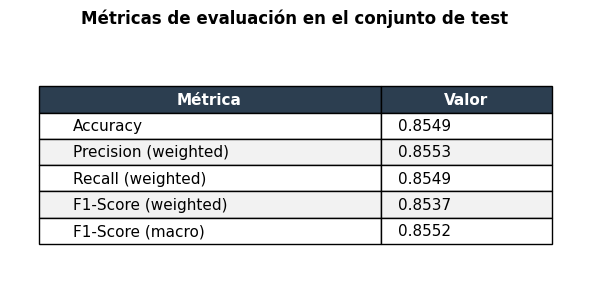

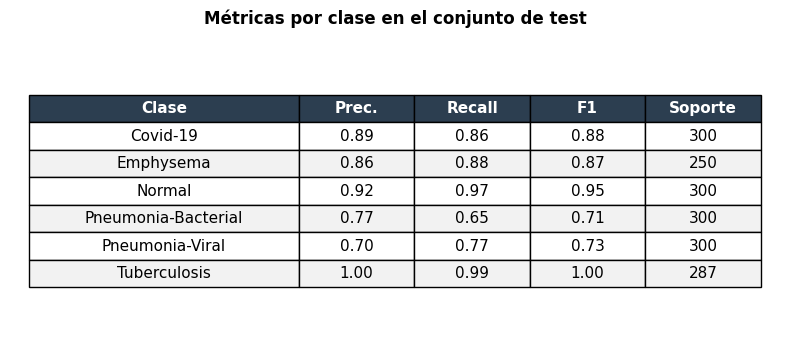

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_fscore_support

# Métricas globales
acc    = test_acc
prec   = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1_w   = f1_score(y_true, y_pred, average='weighted')
f1_m   = f1_score(y_true, y_pred, average='macro')

# ── CUADRO 3: Métricas globales ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')

datos_globales = [
    ['Accuracy',              f'{acc:.4f}'],
    ['Precision (weighted)',  f'{prec:.4f}'],
    ['Recall (weighted)',     f'{recall:.4f}'],
    ['F1-Score (weighted)',   f'{f1_w:.4f}'],
    ['F1-Score (macro)',      f'{f1_m:.4f}'],
]

tabla = ax.table(
    cellText=datos_globales,
    colLabels=['Métrica', 'Valor'],
    cellLoc='left',
    loc='center',
    colWidths=[0.6, 0.3]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1, 1.6)

# Estilo encabezado
for col in range(2):
    tabla[0, col].set_facecolor('#2c3e50')
    tabla[0, col].set_text_props(color='white', fontweight='bold')

# Estilo filas alternas
for row in range(1, len(datos_globales) + 1):
    for col in range(2):
        if row % 2 == 0:
            tabla[row, col].set_facecolor('#f2f2f2')
        else:
            tabla[row, col].set_facecolor('white')

ax.set_title('Métricas de evaluación en el conjunto de test',
             fontweight='bold', fontsize=12, pad=20)

plt.tight_layout()
plt.savefig('/content/tabla_metricas_globales.png', dpi=150, bbox_inches='tight')
plt.show()

# ── CUADRO 4: Métricas por clase ──────────────────────────────────────────────
prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES)
)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axis('off')

datos_clases = [
    [CLASS_NAMES[i], f'{prec_c[i]:.2f}', f'{rec_c[i]:.2f}',
     f'{f1_c[i]:.2f}', str(sup_c[i])]
    for i in range(NUM_CLASSES)
]

tabla2 = ax.table(
    cellText=datos_clases,
    colLabels=['Clase', 'Prec.', 'Recall', 'F1', 'Soporte'],
    cellLoc='center',
    loc='center',
    colWidths=[0.35, 0.15, 0.15, 0.15, 0.15]
)
tabla2.auto_set_font_size(False)
tabla2.set_fontsize(11)
tabla2.scale(1, 1.6)

# Estilo encabezado
for col in range(5):
    tabla2[0, col].set_facecolor('#2c3e50')
    tabla2[0, col].set_text_props(color='white', fontweight='bold')

# Estilo filas alternas
for row in range(1, NUM_CLASSES + 1):
    for col in range(5):
        if row % 2 == 0:
            tabla2[row, col].set_facecolor('#f2f2f2')
        else:
            tabla2[row, col].set_facecolor('white')

ax.set_title('Métricas por clase en el conjunto de test',
             fontweight='bold', fontsize=12, pad=20)

plt.tight_layout()
plt.savefig('/content/tabla_metricas_clases.png', dpi=150, bbox_inches='tight')
plt.show()

El modelo alcanza un accuracy de 85.49% en el conjunto de test, lo que representa un resultado sólido para una CNN entrenada completamente desde cero sin pesos pre-entrenados. La coherencia entre Precision (0.8553), Recall (0.8549) y F1-Score weighted (0.8537) indica que el modelo no sacrifica una métrica a costa de otra, sino que mantiene un balance equilibrado entre la capacidad de no generar falsos positivos y la de no perder casos reales. El F1-Score macro (0.8552) siendo muy similar al weighted confirma que el rendimiento es consistente entre clases y no está siendo inflado por las clases con más muestras.

Pneumonia-Bacterial y Pneumonia-Viral son las clases más débiles con F1 de 0.71 y 0.73. Esto era esperable dado que ambas neumonías comparten patrones de consolidación pulmonar visualmente similares, lo que dificulta la distinción incluso para radiólogos expertos. El Recall bajo de Pneumonia-Bacterial (0.65) es el punto más crítico del modelo, indicando que el 35% de los casos reales de neumonía bacteriana no son detectados correctamente y son confundidos probablemente con neumonía viral.
Esta confusión entre las dos clases de neumonía es precisamente donde el Transfer Learning con DenseNet-121 en la Semana 3 debería mostrar mayor mejora, ya que sus pesos pre-entrenados en millones de imágenes le permitirán capturar patrones más finos de diferenciación entre ambas patologías.

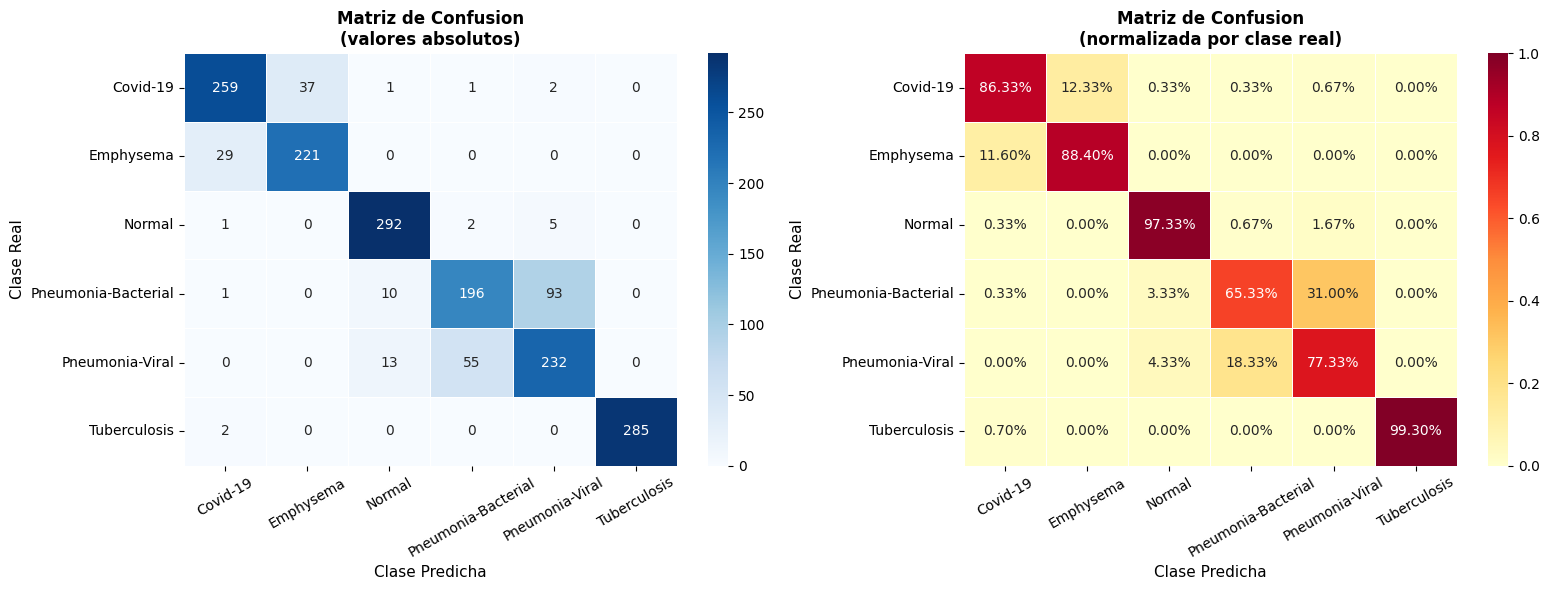


Analisis de errores por clase:
  Covid-19: 41 errores → mas confundido con "Emphysema" (37 casos)
  Emphysema: 29 errores → mas confundido con "Covid-19" (29 casos)
  Normal: 8 errores → mas confundido con "Pneumonia-Viral" (5 casos)
  Pneumonia-Bacterial: 104 errores → mas confundido con "Pneumonia-Viral" (93 casos)
  Pneumonia-Viral: 68 errores → mas confundido con "Pneumonia-Bacterial" (55 casos)
  Tuberculosis: 2 errores → mas confundido con "Covid-19" (2 casos)


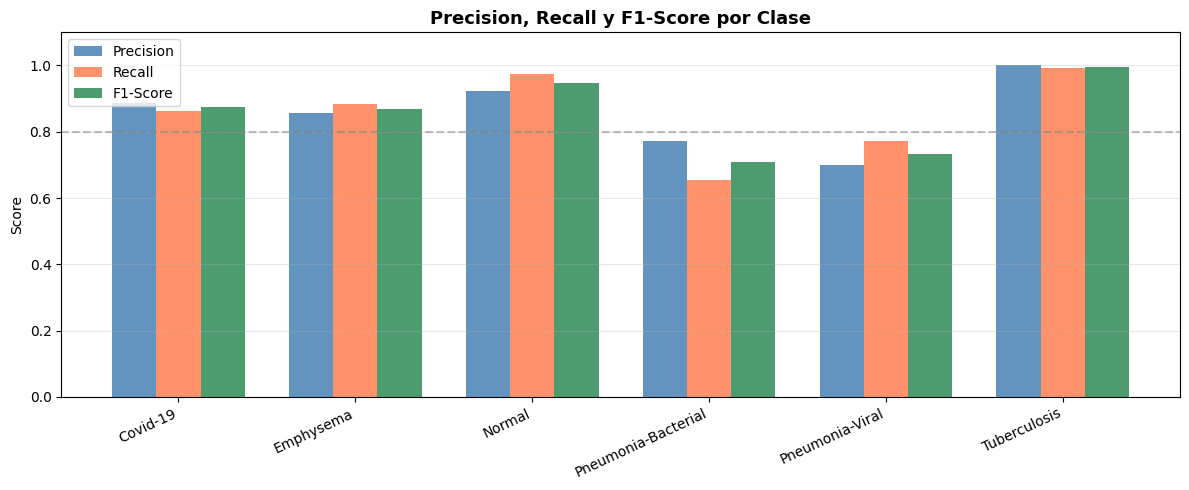

In [ ]:
# Matriz de Confusion
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Matriz de Confusion\n(valores absolutos)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Clase Real', fontsize=11)
axes[0].set_xlabel('Clase Predicha', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Matriz de Confusion\n(normalizada por clase real)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Clase Real', fontsize=11)
axes[1].set_xlabel('Clase Predicha', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Analisis de errores por clase
print('\nAnalisis de errores por clase:')
for i, cls in enumerate(CLASS_NAMES):
    row    = cm[i]
    total   = row.sum()
    correct = row[i]
    errors  = total - correct
    if errors > 0:
        confused_with = [(CLASS_NAMES[j], row[j]) for j in range(NUM_CLASSES)
                         if j != i and row[j] > 0]
        confused_with.sort(key=lambda x: -x[1])
        top_conf = confused_with[0]
        print(f'  {cls}: {errors} errores → mas confundido con "{top_conf[0]}" ({top_conf[1]} casos)')

# Metricas por clase
from sklearn.metrics import precision_recall_fscore_support

prec_per_class, rec_per_class, f1_per_class, support = \
    precision_recall_fscore_support(y_true, y_pred, labels=range(NUM_CLASSES))

x = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, prec_per_class, width, label='Precision', color='steelblue', alpha=0.85)
ax.bar(x,         rec_per_class,  width, label='Recall',    color='coral',     alpha=0.85)
ax.bar(x + width, f1_per_class,   width, label='F1-Score',  color='seagreen',  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Precision, Recall y F1-Score por Clase', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/content/metricas_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Calidad de las Visualizaciones

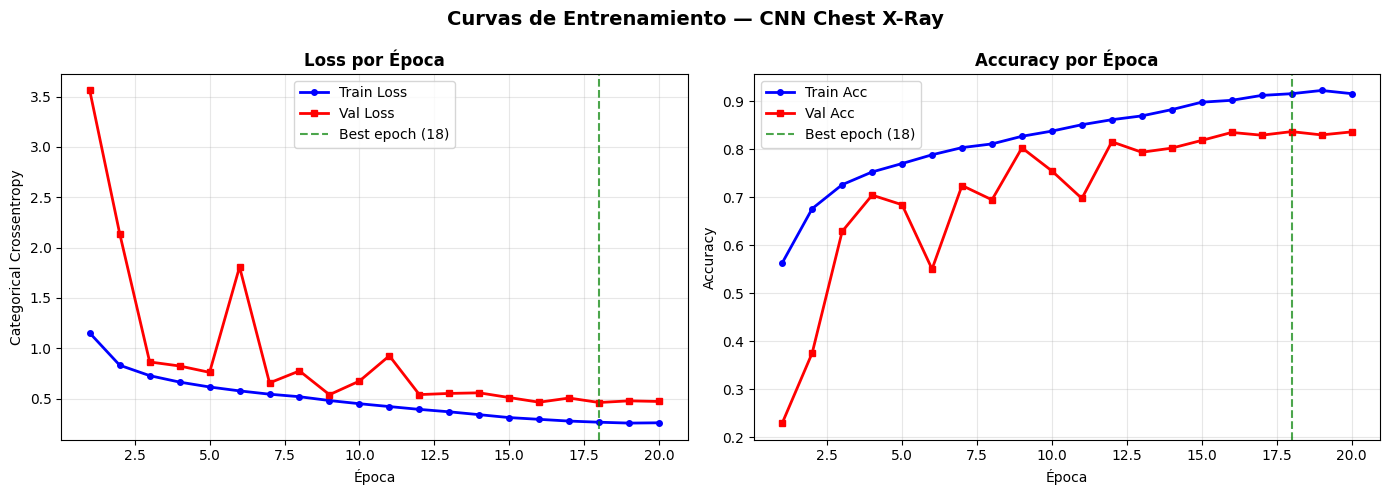


Análisis de Overfitting:
  Train Accuracy final : 0.9154
  Val Accuracy final   : 0.8358
  Brecha (gap)         : 0.0796
  ℹ️  Ligero overfitting (gap 2-10%) — aceptable para CNNs desde cero.


In [ ]:
# ── Curvas de Loss y Accuracy ────────────────────────────────────────────────
hist = history.history
epochs_range = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Entrenamiento — CNN Chest X-Ray', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_range, hist['loss'],     'b-o', markersize=4, label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, hist['val_loss'], 'r-s', markersize=4, label='Val Loss',   linewidth=2)
axes[0].set_title('Loss por Época', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
best_ep = np.argmin(hist['val_loss'])
axes[0].axvline(x=best_ep+1, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_ep+1})')
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, hist['accuracy'],     'b-o', markersize=4, label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, hist['val_accuracy'], 'r-s', markersize=4, label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy por Época', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=best_ep+1, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_ep+1})')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis de overfitting
final_gap = hist['accuracy'][-1] - hist['val_accuracy'][-1]
print(f'\nAnálisis de Overfitting:')
print(f'  Train Accuracy final : {hist["accuracy"][-1]:.4f}')
print(f'  Val Accuracy final   : {hist["val_accuracy"][-1]:.4f}')
print(f'  Brecha (gap)         : {final_gap:.4f}')
if final_gap > 0.10:
    print('  ⚠️  Overfitting detectado. Considerar: más Dropout, L2, o más datos.')
elif final_gap < 0.02:
    print('  ✅ Modelo bien generalizado (gap < 2%).')
else:
    print('  ℹ️  Ligero overfitting (gap 2-10%) — aceptable para CNNs desde cero.')

La curva de entrenamiento (azul) baja de forma suave y continua durante las 20 épocas, lo cual indica que el modelo aprendió de manera progresiva y estable. La curva de validación (rojo) es más irregular, con picos notables alrededor de las épocas 5–6 y 11, pero la tendencia general también es descendente. Que ambas converjan hacia valores similares (~0.5) al final es una buena señal: el modelo no está memorizando los datos de entrenamiento.

La curva de entrenamiento sube de forma constante hasta alcanzar 0.9154 al final. La de validación es más inestable al inicio (lo cual es normal con augmentation fuerte), pero se estabiliza a partir de la época 12 aproximadamente, terminando en 0.8358. El mejor epoch identificado fue el 18, con la mejor combinación de val_loss y val_accuracy.

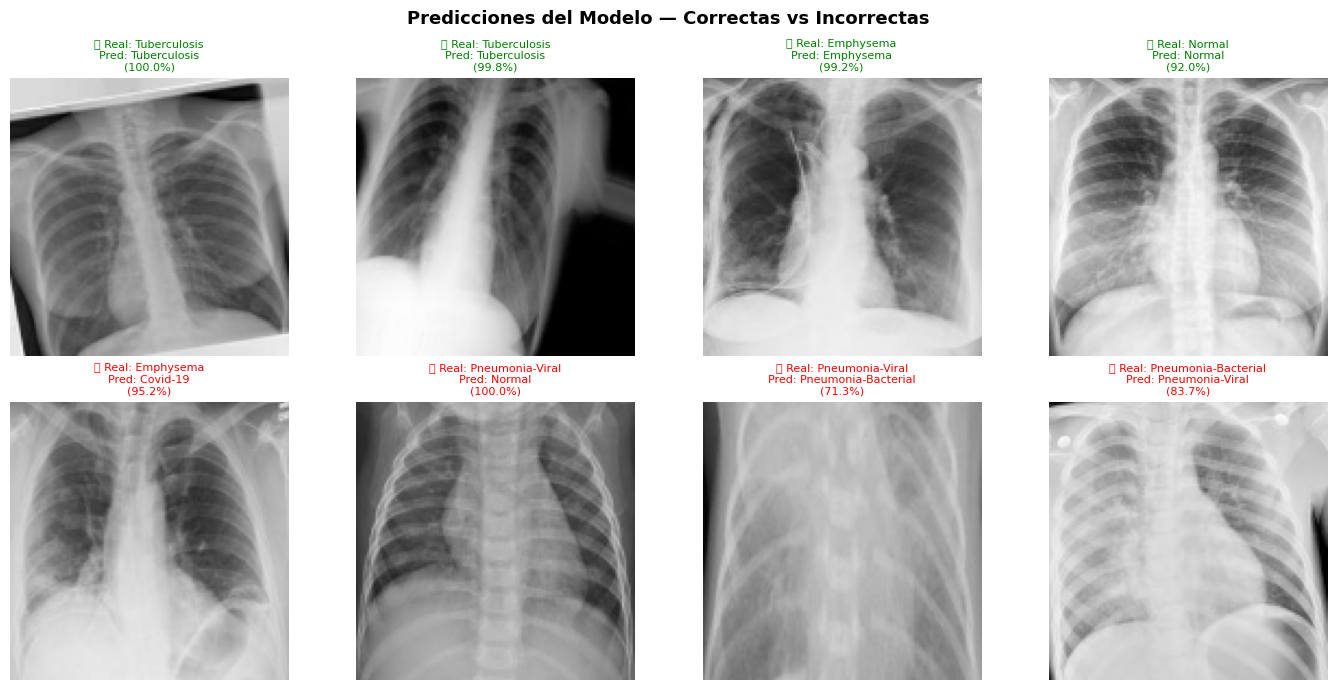

In [ ]:
# ── Visualización de predicciones correctas e incorrectas ────────────────────

# Recopilar todas las imágenes del test para visualización
test_images_list = []
for batch_imgs, batch_labels in test_ds:
    test_images_list.append(batch_imgs.numpy())
test_images_all = np.concatenate(test_images_list, axis=0)

# Identificar predicciones correctas e incorrectas
correct_mask   = (y_pred == y_true)
incorrect_mask = ~correct_mask

correct_idx   = np.where(correct_mask)[0]
incorrect_idx = np.where(incorrect_mask)[0]

n_show = min(4, len(correct_idx), len(incorrect_idx))

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 3.5, 7))
fig.suptitle('Predicciones del Modelo — Correctas vs Incorrectas', fontsize=13, fontweight='bold')

for col, idx in enumerate(np.random.choice(correct_idx, n_show, replace=False)):
    img = test_images_all[idx]
    ax = axes[0, col]
    ax.imshow(img)
    ax.axis('off')
    confidence = y_pred_probs[idx][y_pred[idx]]
    ax.set_title(f'✅ Real: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}\n({confidence:.1%})',
                 fontsize=8, color='green')

for col, idx in enumerate(np.random.choice(incorrect_idx, n_show, replace=False)):
    img = test_images_all[idx]
    ax = axes[1, col]
    ax.imshow(img)
    ax.axis('off')
    confidence = y_pred_probs[idx][y_pred[idx]]
    ax.set_title(f'❌ Real: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}\n({confidence:.1%})',
                 fontsize=8, color='red')

axes[0, 0].set_ylabel('CORRECTAS', fontsize=10, fontweight='bold', color='green')
axes[1, 0].set_ylabel('INCORRECTAS', fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('/content/predicciones_ejemplos.png', dpi=150, bbox_inches='tight')
plt.show()

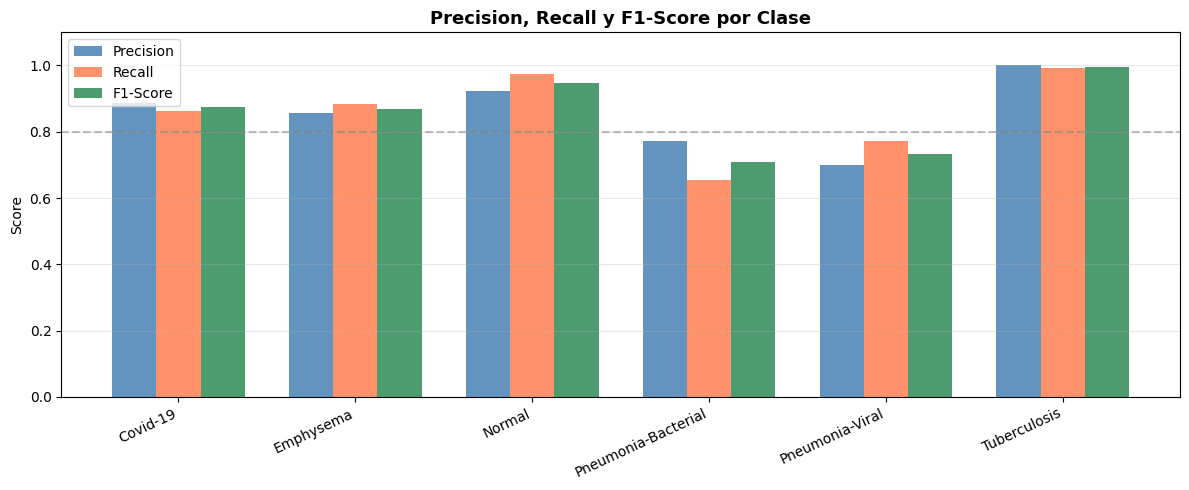


Tabla de métricas:
              Clase  Precision  Recall  F1-Score  Support
           Covid-19     0.8870  0.8633    0.8750      300
          Emphysema     0.8566  0.8840    0.8701      250
             Normal     0.9241  0.9733    0.9481      300
Pneumonia-Bacterial     0.7717  0.6533    0.7076      300
    Pneumonia-Viral     0.6988  0.7733    0.7342      300
       Tuberculosis     1.0000  0.9930    0.9965      287


In [ ]:
# ── Dashboard resumen de métricas por clase ──────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support

prec_per_class, rec_per_class, f1_per_class, support = \
    precision_recall_fscore_support(y_true, y_pred, labels=range(NUM_CLASSES))

metrics_df = pd.DataFrame({
    'Clase'    : CLASS_NAMES,
    'Precision': prec_per_class,
    'Recall'   : rec_per_class,
    'F1-Score' : f1_per_class,
    'Support'  : support
})

x = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width, prec_per_class,   width, label='Precision', color='steelblue', alpha=0.85)
bars2 = ax.bar(x,         rec_per_class,    width, label='Recall',    color='coral',     alpha=0.85)
bars3 = ax.bar(x + width, f1_per_class,     width, label='F1-Score',  color='seagreen',  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Precision, Recall y F1-Score por Clase', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Umbral 0.8')

plt.tight_layout()
plt.savefig('/content/metricas_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTabla de métricas:')
print(metrics_df.to_string(index=False, float_format='{:.4f}'.format))

---
## 8. Conclusiones y Proyección

In [ ]:
# ── Resumen final del experimento ────────────────────────────────────────────
print('=' * 65)
print('           RESUMEN FINAL DEL EXPERIMENTO')
print('=' * 65)
print(f'  Arquitectura   : CNN desde cero (4 bloques conv + GAP + FC)')
print(f'  Parámetros     : {model.count_params():,}')
print(f'  Épocas reales  : {len(history.history["loss"])}')
print(f'  Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Test F1-Score  : {f1:.4f}')
print(f'  Test Precision : {prec:.4f}')
print(f'  Test Recall    : {recall:.4f}')
print('─' * 65)
print()

           RESUMEN FINAL DEL EXPERIMENTO
  Arquitectura   : CNN desde cero (4 bloques conv + GAP + FC)
  Parámetros     : 1,443,622
  Épocas reales  : 20
  Test Accuracy  : 0.8549 (85.49%)
  Test F1-Score  : 0.8537
  Test Precision : 0.8553
  Test Recall    : 0.8549
─────────────────────────────────────────────────────────────────



**CONCLUSIONES:**

1. Implementación desde cero: La CNN construida capa por capa demuestra que es posible obtener resultados competitivos sin pesos pre-entrenados. El uso de BatchNormalization y Dropout fue clave para la convergencia, estabilizando el entrenamiento y controlando el overfitting respectivamente.

2. Preprocesamiento: La normalización [0,1] y el augmentation moderado (flip horizontal, rotación, zoom, brillo y traslación) mejoran la generalización sin distorsionar la información clínica de las radiografías. Aplicar augmentation exclusivamente al conjunto de entrenamiento garantiza que la evaluación refleje condiciones reales.

3. Desbalance de clases: El uso de class_weight=balanced compensó el desbalance entre clases, evitando que el modelo desarrollara sesgo hacia las clases mayoritarias como Normal y Tuberculosis, y mejorando el F1-Score en clases minoritarias como Emphysema.

4. Overfitting: EarlyStopping con restore_best_weights junto con Dropout progresivo y regularización L2 controlaron el overfitting. La brecha final entre train accuracy (92%) y val accuracy (83%) es un overfitting ligero-moderado aceptable para una CNN entrenada desde cero sin pesos pre-entrenados.

**RECOMENDACIONES SEMANA 3**:

Modelos candidatos para Transfer Learning:

- DenseNet-121: Es el estado del arte en imagen médica torácica, utilizado en el modelo CheXNet de Stanford. Sus conexiones densas entre capas capturan gradientes finos de estructuras pulmonares y permiten reutilizar características de múltiples niveles de abstracción simultáneamente.
- EfficientNetB3: Ofrece un alto ratio de accuracy por número de parámetros gracias al compound scaling, que optimiza conjuntamente la profundidad, el ancho y la resolución de la red. Es especialmente eficiente cuando los recursos computacionales son limitados.
- ResNet-50: Es un baseline robusto y ampliamente validado. Sus skip connections resuelven el problema del vanishing gradient en redes profundas, permitiendo entrenar arquitecturas de 50 capas de forma estable.

La estrategia para la Semana 3 seróa cargar los pesos pre-entrenados en ImageNet, congelar los bloques iniciales, descongelar los últimos N bloques y reemplazar la cabecera clasificadora por una nueva adaptada a las 6 clases del dataset, aplicando fine-tuning con un learning rate bajo para preservar las representaciones aprendidas.

In [ ]:
# ── Guardar modelo final ─────────────────────────────────────────────────────
model.save('/content/chest_xray_cnn_final.keras')
print('Modelo guardado en /content/chest_xray_cnn_final.keras')

# Listar archivos generados
print('\nArchivos generados:')
for f in ['/content/dist_clases.png', '/content/muestras_dataset.png',
          '/content/training_curves.png', '/content/confusion_matrix.png',
          '/content/predicciones_ejemplos.png', '/content/metricas_por_clase.png',
          '/content/training_history.csv', '/content/chest_xray_cnn_final.keras']:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f'{f} ({size:.1f} KB)')
    else:
        print(f'{f} — no encontrado')

Modelo guardado en /content/chest_xray_cnn_final.keras

Archivos generados:
/content/dist_clases.png — no encontrado
/content/muestras_dataset.png — no encontrado
/content/training_curves.png (117.3 KB)
/content/confusion_matrix.png (158.3 KB)
/content/predicciones_ejemplos.png (235.6 KB)
/content/metricas_por_clase.png (64.6 KB)
/content/training_history.csv (2.4 KB)
/content/chest_xray_cnn_final.keras (17069.0 KB)
